**IMPORT LIBRARY & LOAD DATA**

Dataset PBJ (Pengadaan Barang/Jasa) di-load dari Google Drive sebagai sumber utama analisis.

In [ ]:
# ============================================
# IMPORT LIBRARY
# ============================================

import pandas as pd
import numpy as np
import re

# ============================================
# CONNECT GOOGLE DRIVE
# ============================================

from google.colab import drive
drive.mount('/content/drive')

# ============================================
# LOAD DATASET
# ============================================

file_path = '/content/drive/MyDrive/S2/SMT 3/tid-master-data.csv'

df = pd.read_csv(file_path)

print("✅ Dataset berhasil dimuat!")

Mounted at /content/drive
✅ Dataset berhasil dimuat!


**VALIDASI DATA**

Validasi awal untuk memastikan struktur dataset sesuai, seperti jumlah baris, kolom, serta memastikan kolom penting seperti paket tersedia untuk proses analisis selanjutnya.

In [ ]:
# ============================================
# CEK JUMLAH DATA
# ============================================

print("Total jumlah data:", len(df))

# ============================================
# CEK KOLOM
# ============================================

print("\nDaftar kolom:")
print(df.columns)

# ============================================
# TAMPILKAN SAMPLE DATA
# ============================================

df.head(5)

Total jumlah data: 3009760

Daftar kolom:
Index(['paket', 'dalamNegeri', 'jenisPengadaan', 'metode', 'lembaga', 'satker',
       'lokasi', 'id', 'pagu', 'pemilihanDate', 'sumberDana', 'isUMKM',
       'volumePekerjaan', 'uraianPekerjaan', 'spesifikasiPekerjaan',
       'ownerType', 'potensiPemborosan', 'tags.isInappropriate',
       'tags.inappropriateReason', 'jumlahTagAktif', '_source_part'],
      dtype='object')


,paket,dalamNegeri,jenisPengadaan,metode,lembaga,satker,lokasi,id,pagu,pemilihanDate,...,isUMKM,volumePekerjaan,uraianPekerjaan,spesifikasiPekerjaan,ownerType,potensiPemborosan,tags.isInappropriate,tags.inappropriateReason,jumlahTagAktif,_source_part
0,Pengadaan Jasa Kurasi Pendukung Kegiatan Sub ...,True,Jasa Lainnya,Pengadaan Langsung,Kementerian Pendidikan Dasar dan Menengah,SEKRETARIAT DITJEN PENDIDIKAN ANAK USIA DINI P...,"DKI Jakarta, Jakarta Pusat (Kota)",61614152,1.000000e+08,January 2026,...,True,1 Paket,Kurasi,Kurasi,central,0.0,low,NaN,0,1
1,Belanja Obat-Obatan dan Bahan Medis-Oksigen da...,True,Barang,E-Purchasing,Kab. Jepara,RSUD RA Kartini,"Jawa Tengah, Jepara (Kab.)",62114349,1.651060e+09,January 2026,...,True,12 Paket,Belanja Obat-Obatan dan Bahan Medis-Oksigen da...,"Oxygen 8 m3 50 btl 12 kali 78,300 46,980,000 O...",kabkota,0.0,low,NaN,0,1
2,Belanja Makanan dan Minuman Jamuan Tamu,True,Barang,Pengadaan Langsung,Kab. Tegal,Kecamatan Dukuhwaru,"Jawa Tengah, Tegal (Kab.)",62539997,3.600000e+06,January 2026,...,True,1 paket,snack dan makan tamu,sesuai dengan KAK,kabkota,0.0,low,NaN,0,1
3,Belanja Jasa Pelayanan Umum,True,Jasa Lainnya,E-Purchasing,Kab. Bulungan,Kecamatan Tanjung Palas,"Kalimantan Utara, Bulungan (Kab.)",62377650,3.100000e+07,December 2025,...,True,1 Paket,Penyediaan jasa tenaga administrasi,"Tenaga teknis, operator aplikasi",kabkota,0.0,low,NaN,0,1
4,Pemeliharaan Kendaraan Dinas Operasional Roda ...,True,Jasa Lainnya,Penunjukan Langsung,"Badan Meteorologi, Klimatologi Dan Geofisika",Stasiun Geofisika Kelas I Kupang,"Nusa Tenggara Timur, Kupang (Kota)",62200988,3.600000e+07,January 2026,...,True,"( 1, UNIT, @ 36000000 )",1. Pemeliharaan Kendaraan Dinas Operasional Ro...,Pemeliharaan Kendaraan Dinas Operasional Roda ...,central,0.0,low,NaN,0,1


**FILTERING DATA INTERNET**

Dataset difilter menggunakan pendekatan rule-based keyword matching pada kolom paket untuk mengekstraksi pengadaan yang berkaitan dengan layanan internet.


In [ ]:
# ============================================
# FILTERING DATA INTERNET
# ============================================

pattern = 'internet'

df_internet = df[
    df['paket'].astype(str).str.lower().str.contains(pattern, na=False)
].copy()

df_internet = df_internet.reset_index(drop=True)

print("Total data setelah filtering:", len(df_internet))

Total data setelah filtering: 27586


In [ ]:
# ============================================
# SIMPAN DATA HASIL FILTER
# ============================================

output_path = '/content/drive/MyDrive/S2/SMT 3/tid-internet-filter.csv'

df_internet.to_csv(output_path, index=False)

print("Data berhasil disimpan ke:", output_path)

Data berhasil disimpan ke: /content/drive/MyDrive/S2/SMT 3/tid-internet-filter.csv


**VALIDASI DATA HASIL FILTER**

Dataset hasil filtering dimuat kembali untuk memastikan proses penyimpanan berjalan dengan baik dan data dapat digunakan pada tahap berikutnya.

In [ ]:
# ============================================
# LOAD DATA SETELAH FILTER
# ============================================

df_check  = pd.read_csv(output_path)

print("Total data:", len(df_check))
print("Total kolom:", len(df_check.columns))

df_check .head(5)

Total data: 27586
Total kolom: 21


,paket,dalamNegeri,jenisPengadaan,metode,lembaga,satker,lokasi,id,pagu,pemilihanDate,...,isUMKM,volumePekerjaan,uraianPekerjaan,spesifikasiPekerjaan,ownerType,potensiPemborosan,tags.isInappropriate,tags.inappropriateReason,jumlahTagAktif,_source_part
0,Pulsa/Paket Internet GSM modem MIFI,True,Barang,Dikecualikan,"Badan Meteorologi, Klimatologi Dan Geofisika",Stasiun Geofisika Kelas III Kepahiang,"Bengkulu, Kepahiang (Kab.)",62208391,540000.0,January 2026,...,True,"( 4, BLN, @ 135000 )","1. Pulsa/Paket Internet GSM modem MIFI ( 4, BL...","1. Pulsa/Paket Internet GSM modem MIFI ( 4, BL...",central,0.0,low,NaN,0,1
1,Koneksi internet,True,Barang,Pengadaan Langsung,Badan Pusat Statistik,BADAN PUSAT STATISTIK KAB SUBANG,"Jawa Barat, Subang (Kab.)",62572514,15201000.0,January 2026,...,True,"( 1, THN, @ 15201000 )","1. Koneksi internet ( 1, THN, @ 15201000 );",Sesuai dengan KAK,central,0.0,low,NaN,0,1
2,Pengadaan Belanja Barang Keperluan Perkantoran...,True,Jasa Lainnya,E-Purchasing,Kementerian Imigrasi dan Pemasyarakatan,IM13 KANTOR IMIGRASI KELAS I TPI SURAKARTA,"Jawa Tengah, Karanganyar (Kab.)",62593069,67804800.0,December 2025,...,True,1 Paket,Langganan Internet 12 BLN,Langganan Internet 12 BLN,central,0.0,low,NaN,0,1
3,Langganan SIMPUS dan Dukungan Internet,True,Barang,Dikecualikan,Kab. Karangasem,UPTD Puskesmas Abang I,"Bali, Karang Asem (Kab.)",62180115,13320000.0,January 2026,...,True,12 bulan,Langganan SIMPUS dan Dukungan Internet,Langganan SIMPUS,kabkota,0.0,low,NaN,0,1
4,Belanja Langganan Internet,True,Jasa Lainnya,Dikecualikan,Kota Balikpapan,UPTD PUSKESMAS MANGGAR,"Kalimantan Timur, Balikpapan (Kota)",62589527,23500000.0,January 2026,...,True,1 Paket,Belanja Langganan Internet,Belanja Langganan Internet Indihome dan Langga...,kabkota,0.0,low,NaN,0,1


**ANALISIS LEMBAGA TERATAS**

Dataset dianalisis untuk mengetahui lembaga dengan jumlah pengadaan internet terbanyak sebagai dasar pemilihan subset data untuk proses similarity.

In [ ]:
# ============================================
# ANALISIS LEMBAGA TERATAS
# ============================================

# hitung jumlah paket per lembaga
top_lembaga = df_internet['lembaga'].value_counts().head(10)

print("Top 10 lembaga dengan paket internet terbanyak:\n")
print(top_lembaga)

Top 10 lembaga dengan paket internet terbanyak:

lembaga
Mahkamah Agung                             690
Badan Pusat Statistik                      560
Kementerian Imigrasi dan Pemasyarakatan    546
Kementerian Agama                          461
Provinsi Jawa Timur                        438
Kab. Bogor                                 306
Kepolisian Negara Republik Indonesia       252
Kota Bandung                               246
Kementerian Agraria dan Tata Ruang/BPN     220
Provinsi Jawa Tengah                       208
Name: count, dtype: int64


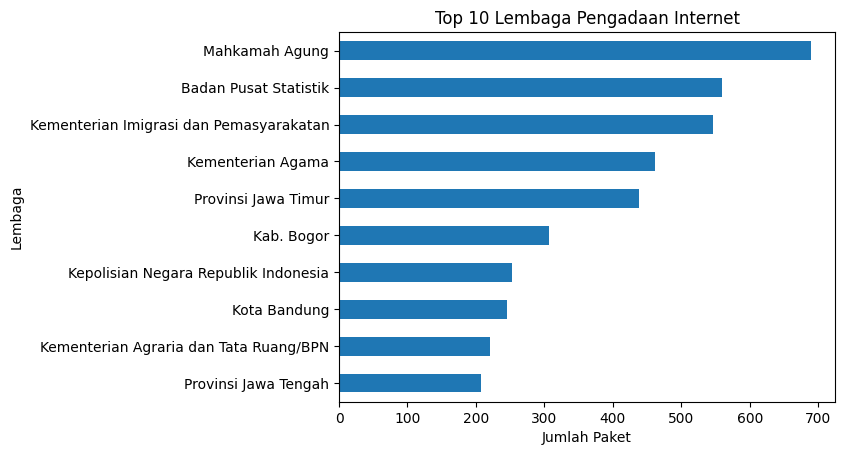

In [ ]:
# ============================================
# VISUALISASI
# ============================================

import matplotlib.pyplot as plt

top_lembaga.plot(kind='barh')
plt.title("Top 10 Lembaga Pengadaan Internet")
plt.xlabel("Jumlah Paket")
plt.ylabel("Lembaga")
plt.gca().invert_yaxis()
plt.show()

**SUBSET DATA LEMBAGA TERPILIH**

Data difokuskan pada beberapa lembaga dengan jumlah paket terbanyak untuk meningkatkan efisiensi komputasi dalam proses similarity.

In [ ]:
# ============================================
# SUBSET DATA BERDASARKAN LEMBAGA TERPILIH
# ============================================

selected_lembaga = [
    'Mahkamah Agung',
    'Badan Pusat Statistik',
    'Kementerian Imigrasi dan Pemasyarakatan',
    'Kementerian Agama ',
    'Provinsi Jawa Timur',
    'Kab. Bogor',
    'Kepolisian Negara Republik Indonesia',
    'Kota Bandung',
    'Kementerian Agraria dan Tata Ruang/BPN',
    'Provinsi Jawa Tengah',
]

df_subset = df_internet[
    df_internet['lembaga'].isin(selected_lembaga)
].copy()

df_subset = df_subset.reset_index(drop=True)

print("Total data subset:", len(df_subset))

Total data subset: 3466


**TEXT NORMALIZATION**

In [ ]:
# ============================================
# TEXT NORMALIZATION (FIXED)
# ============================================

import re

if 'paket_clean' in df_subset.columns:
    df_subset = df_subset.drop(columns=['paket_clean'])

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\b20\d{2}\b', '', text)

    stopwords = [
        'tahun', 'anggaran', 'kegiatan', 'sub', 'paket',
        'pekerjaan', 'penyediaan', 'jasa'
    ]

    pattern = r'\b(' + '|'.join(stopwords) + r')\b'
    text = re.sub(pattern, '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_subset['paket_clean'] = df_subset['paket'].apply(normalize_text)

**TF-IDF VECTORIZATION (NAMA PAKET)**

Kolom paket diubah menjadi representasi numerik menggunakan TF-IDF untuk menghitung tingkat kemiripan antar teks.

In [ ]:
# ============================================
# TF-IDF UPGRADE
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    token_pattern=r'(?u)\b\w+\b'
)

tfidf_matrix = vectorizer.fit_transform(df_subset['paket_clean'])

**COSINE SIMILARITY**

Menghitung kemiripan antar nama paket menggunakan cosine similarity.

In [ ]:
# ============================================
# COSINE SIMILARITY
# ============================================

from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(tfidf_matrix)

**GENERATE PAIR**

Pasangan paket dengan similarity tinggi diambil sebagai kandidat untuk proses labeling dan analisis lebih lanjut.

In [ ]:
# ============================================
# GENERATE PAIR >= 0.8
# ============================================

pairs = []
threshold = 0.8

n = len(df_subset)

for i in range(n):
    for j in range(i+1, n):
        sim = sim_matrix[i, j]

        if sim >= threshold:
            pairs.append({
                'idx1': i,
                'idx2': j,
                'paket_A': df_subset.loc[i, 'paket'],
                'paket_B': df_subset.loc[j, 'paket'],
                'sim_nama': sim
            })

pairs_df = pd.DataFrame(pairs)

print("Jumlah pasangan (>=0.8):", len(pairs_df))
pairs_df.head()

Jumlah pasangan (>=0.8): 307005


,idx1,idx2,paket_A,paket_B,sim_nama
0,0,62,Koneksi internet,Koneksi internet,1.0
1,0,91,Koneksi internet,Koneksi internet,1.0
2,0,174,Koneksi internet,Koneksi internet,1.0
3,0,226,Koneksi internet,Koneksi internet,1.0
4,0,228,Koneksi internet,Koneksi internet,1.0


**SIMPAN KE CSV**

In [ ]:
# ============================================
# SIMPAN CSV SIMILARITY
# ============================================

output_path = '/content/drive/MyDrive/S2/SMT 3/similarity_pairs.csv'

pairs_df.to_csv(output_path, index=False)

print("CSV berhasil disimpan di:", output_path)

CSV berhasil disimpan di: /content/drive/MyDrive/S2/SMT 3/similarity_pairs.csv


**GENERATE PAIR**

In [ ]:
# ============================================
# FILTER: 0.8 ≤ SIM < 1.0
# ============================================

pairs_filtered = pairs_df[
    (pairs_df['sim_nama'] >= 0.8) &
    (pairs_df['sim_nama'] < 1.0)
].copy()

print("Jumlah pasangan (0.8 ≤ sim < 1.0):", len(pairs_filtered))

pairs_filtered.head(20)

Jumlah pasangan (0.8 ≤ sim < 1.0): 2712


,idx1,idx2,paket_A,paket_B,sim_nama
461,1,1257,Pengadaan Belanja Barang Keperluan Perkantoran...,Pengadaan Belanja Barang Keperluan Perkantoran...,0.933063
462,2,1295,Langganan Internet T.A 2026,Biaya Internet T.A 2026,0.830115
463,2,2669,Langganan Internet T.A 2026,INTERNET T.A. 2026,0.970262
464,2,2948,Langganan Internet T.A 2026,Biaya Internet T.A. 2026,0.830115
465,4,738,Belanja Barang dan Jasa BLUD - Belanja Kawat/F...,Belanja Barang dan Jasa BLUD - Belanja Kawat/F...,0.921932
1010,7,3119,Belanja Barang dan Jasa BLUD - Belanja Kawat/F...,Belanja Barang dan Jasa BLUD - Belanja Kawat/F...,0.902022
1011,7,3365,Belanja Barang dan Jasa BLUD - Belanja Kawat/F...,Belanja Barang dan Jasa BLUD - Belanja Kawat/F...,0.894390
1076,9,3069,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.835089
2308,13,1933,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Kawat/Faksimili/Internet/TV Berlangganan,0.912853
2380,13,2503,Belanja Kawat/Faksimili/Internet/TV Berlangganan,nja Kawat/Faksimili/Internet/TV Berlangganan,0.912853


**SIMPAN KE CSV**

In [ ]:
output_path = '/content/drive/MyDrive/S2/SMT 3/similarity_pairs_filtered.csv'
pairs_filtered.to_csv(output_path, index=False)

print("Saved ke:", output_path)
print("Total pair:", len(pairs_filtered))

Saved ke: /content/drive/MyDrive/S2/SMT 3/similarity_pairs_filtered.csv
Total pair: 2712


In [ ]:
pairs_filtered = pairs_df[
    (pairs_df['sim_nama'] >= 0.8) &
    (pairs_df['sim_nama'] < 1.0)
]

In [ ]:
sample_pairs = pairs_filtered.sample(30, random_state=42)
sample_pairs

,idx1,idx2,paket_A,paket_B,sim_nama,label
137104,726,1169,Langganan Biaya Internet,BIAYA INTERNET,0.962821,1.0
246650,1915,2987,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.841583,1.0
252409,2030,2445,Belanja Kawat/ Faksimili/ Internet/ TV berlang...,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.848400,1.0
262381,2312,2345,Belanja kawat/faksimili/internet/TV berlanggan...,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.848400,1.0
292034,3077,3138,Kawat/Faksimili/Internet/TV Berlangganan,Belanja Kawat/Faksimili/Internet/TV Berlangganan,0.912853,1.0
67569,365,2472,Pengadaan Langganan Internet pada Rumah Tahana...,Pengadaan jasa lainnya Langganan Internet Pada...,0.866729,1.0
118245,611,1933,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Kawat/Faksimili/Internet/TV Berlangganan,0.912853,1.0
245420,1894,2351,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.848400,1.0
165308,947,1414,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.819725,1.0
258052,2250,2267,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,Belanja Kawat /Faksimili/Internet/TV Berlangga...,0.806734,1.0


In [ ]:
# ============================================
# FILTER DATA
# ============================================

pairs_filtered = pairs_df[
    (pairs_df['sim_nama'] >= 0.8) &
    (pairs_df['sim_nama'] < 1.0)
].copy()

print("Jumlah pasangan:", len(pairs_filtered))

Jumlah pasangan: 2712


In [ ]:
# ============================================
# TF-IDF PER KOLOM
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def compute_similarity(series):
    vectorizer = TfidfVectorizer(min_df=1)
    tfidf = vectorizer.fit_transform(series.astype(str))
    return cosine_similarity(tfidf)

sim_paket = compute_similarity(df_subset['paket'])
sim_uraian = compute_similarity(df_subset['uraianPekerjaan'])
sim_metode = compute_similarity(df_subset['metode'])

**HITUNG SIMILARITY PER KOLOM**

In [ ]:
# ============================================
# TF-IDF PER KOLOM
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def compute_similarity(series):
    vectorizer = TfidfVectorizer(min_df=1)
    tfidf = vectorizer.fit_transform(series.astype(str))
    return cosine_similarity(tfidf)

sim_paket = compute_similarity(df_subset['paket'])
sim_uraian = compute_similarity(df_subset['uraianPekerjaan'])
sim_metode = compute_similarity(df_subset['metode'])

**HITUNG WEIGHTED SCORE**

In [ ]:
# ============================================
# WEIGHTED SCORING
# ============================================

pairs_filtered = pairs_filtered.copy()

# w_paket = 0.5
# w_uraian = 0.3
# w_metode = 0.2

w_paket = 0.7
w_uraian = 0.2
w_metode = 0.1

weighted_scores = [
    (w_paket * sim_paket[int(i), int(j)] +
     w_uraian * sim_uraian[int(i), int(j)] +
     w_metode * sim_metode[int(i), int(j)])
    for i, j in zip(pairs_filtered['idx1'], pairs_filtered['idx2'])
]

pairs_filtered.loc[:, 'weighted_score'] = weighted_scores

pairs_filtered['prediksi'] = pairs_filtered['weighted_score'] >= 0.75

In [ ]:
# ============================================
# HITUNG KONTRIBUSI PER KOLOM
# ============================================

paket_scores = []
uraian_scores = []
metode_scores = []
total_scores = []

for i, j in zip(pairs_filtered['idx1'], pairs_filtered['idx2']):
    i = int(i)
    j = int(j)

    s_paket = sim_paket[i, j]
    s_uraian = sim_uraian[i, j]
    s_metode = sim_metode[i, j]

    w_p = w_paket * s_paket
    w_u = w_uraian * s_uraian
    w_m = w_metode * s_metode

    total = w_p + w_u + w_m

    paket_scores.append(w_p)
    uraian_scores.append(w_u)
    metode_scores.append(w_m)
    total_scores.append(total)

pairs_filtered = pairs_filtered.copy()

pairs_filtered['score_paket'] = paket_scores
pairs_filtered['score_uraian'] = uraian_scores
pairs_filtered['score_metode'] = metode_scores
pairs_filtered['weighted_score'] = total_scores

In [ ]:
pairs_filtered.head()

,idx1,idx2,paket_A,paket_B,sim_nama,label,weighted_score,prediksi,score_paket,score_uraian,score_metode
461,1,1257,Pengadaan Belanja Barang Keperluan Perkantoran...,Pengadaan Belanja Barang Keperluan Perkantoran...,0.933063,NaN,0.877275,True,0.677275,0.200000,0.0
462,2,1295,Langganan Internet T.A 2026,Biaya Internet T.A 2026,0.830115,NaN,0.320890,False,0.318816,0.002074,0.0
463,2,2669,Langganan Internet T.A 2026,INTERNET T.A. 2026,0.970262,NaN,0.676734,False,0.576734,0.000000,0.1
464,2,2948,Langganan Internet T.A 2026,Biaya Internet T.A. 2026,0.830115,NaN,0.350432,False,0.318816,0.031617,0.0
465,4,738,Belanja Barang dan Jasa BLUD - Belanja Kawat/F...,Belanja Barang dan Jasa BLUD - Belanja Kawat/F...,0.921932,NaN,0.827866,True,0.580510,0.147356,0.1


In [97]:
output_path = '/content/drive/MyDrive/S2/SMT 3/pairs_filtered.csv'

pairs_filtered.to_csv(output_path, index=False)

print("CSV berhasil disimpan di:", output_path)

CSV berhasil disimpan di: /content/drive/MyDrive/S2/SMT 3/pairs_filtered.csv


In [ ]:
# ============================================
# WEIGHTED SCORING
# ============================================

# w_paket = 0.5
# w_uraian = 0.3
# w_metode = 0.2

w_paket = 0.7
w_uraian = 0.2
w_metode = 0.1

paket_scores = []
uraian_scores = []
metode_scores = []
total_scores = []

for i, j in zip(pairs_filtered['idx1'], pairs_filtered['idx2']):
    i = int(i)
    j = int(j)

    s_paket = sim_paket[i, j]
    s_uraian = sim_uraian[i, j]
    s_metode = sim_metode[i, j]

    w_p = w_paket * s_paket
    w_u = w_uraian * s_uraian
    w_m = w_metode * s_metode

    total = w_p + w_u + w_m

    paket_scores.append(w_p)
    uraian_scores.append(w_u)
    metode_scores.append(w_m)
    total_scores.append(total)

pairs_filtered['score_paket'] = paket_scores
pairs_filtered['score_uraian'] = uraian_scores
pairs_filtered['score_metode'] = metode_scores
pairs_filtered['weighted_score'] = total_scores

In [ ]:
# ============================================
# PREDIKSI
# ============================================

pairs_filtered['prediksi'] = pairs_filtered['weighted_score'] >= 0.75

**MANUAL LABELING**

In [ ]:
pairs_df.loc[137104, 'label'] = 1
pairs_df.loc[246650, 'label'] = 1
pairs_df.loc[252409, 'label'] = 1
pairs_df.loc[262381, 'label'] = 1
pairs_df.loc[292034, 'label'] = 1
pairs_df.loc[67569,  'label'] = 1
pairs_df.loc[118245, 'label'] = 1
pairs_df.loc[245420, 'label'] = 1
pairs_df.loc[165308, 'label'] = 1
pairs_df.loc[258052, 'label'] = 1
pairs_df.loc[247623, 'label'] = 1
pairs_df.loc[250557, 'label'] = 1
pairs_df.loc[263422, 'label'] = 1
pairs_df.loc[114371, 'label'] = 1
pairs_df.loc[234429, 'label'] = 0
pairs_df.loc[250811, 'label'] = 1
pairs_df.loc[187011, 'label'] = 1
pairs_df.loc[247488, 'label'] = 1
pairs_df.loc[266681, 'label'] = 1
pairs_df.loc[128452, 'label'] = 1
pairs_df.loc[272981, 'label'] = 1
pairs_df.loc[231094, 'label'] = 1
pairs_df.loc[245995, 'label'] = 1
pairs_df.loc[259163, 'label'] = 1
pairs_df.loc[148927, 'label'] = 1
pairs_df.loc[275913, 'label'] = 1
pairs_df.loc[149454, 'label'] = 1
pairs_df.loc[244263, 'label'] = 1
pairs_df.loc[225793, 'label'] = 1
pairs_df.loc[247590, 'label'] = 1

In [104]:
pairs_df.loc[(pairs_df['idx1']==1) & (pairs_df['idx2']==1257), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==2) & (pairs_df['idx2']==1295), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==2) & (pairs_df['idx2']==2669), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==2) & (pairs_df['idx2']==2948), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==4) & (pairs_df['idx2']==738), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==7) & (pairs_df['idx2']==3119), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==7) & (pairs_df['idx2']==3365), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==9) & (pairs_df['idx2']==3069), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==13) & (pairs_df['idx2']==1933), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==13) & (pairs_df['idx2']==2503), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==13) & (pairs_df['idx2']==2837), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==13) & (pairs_df['idx2']==2987), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==13) & (pairs_df['idx2']==3077), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==18) & (pairs_df['idx2']==27), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==18) & (pairs_df['idx2']==33), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==22) & (pairs_df['idx2']==233), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==27) & (pairs_df['idx2']==33), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==31) & (pairs_df['idx2']==111), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==31) & (pairs_df['idx2']==113), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==31) & (pairs_df['idx2']==748), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==32) & (pairs_df['idx2']==726), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==36) & (pairs_df['idx2']==206), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==36) & (pairs_df['idx2']==208), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==36) & (pairs_df['idx2']==1171), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==36) & (pairs_df['idx2']==1294), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==37) & (pairs_df['idx2']==870), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==37) & (pairs_df['idx2']==1485), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==46) & (pairs_df['idx2']==1933), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==46) & (pairs_df['idx2']==2503), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==46) & (pairs_df['idx2']==2837), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==46) & (pairs_df['idx2']==2987), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==46) & (pairs_df['idx2']==3077), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==48) & (pairs_df['idx2']==1375), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==48) & (pairs_df['idx2']==1571), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==48) & (pairs_df['idx2']==2991), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==57) & (pairs_df['idx2']==1640), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==58) & (pairs_df['idx2']==1785), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==61) & (pairs_df['idx2']==795), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==61) & (pairs_df['idx2']==924), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==61) & (pairs_df['idx2']==943), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==61) & (pairs_df['idx2']==1021), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==61) & (pairs_df['idx2']==1030), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==61) & (pairs_df['idx2']==1096), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==61) & (pairs_df['idx2']==1102), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==61) & (pairs_df['idx2']==1104), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==61) & (pairs_df['idx2']==1114), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==61) & (pairs_df['idx2']==1116), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==61) & (pairs_df['idx2']==1150), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==71) & (pairs_df['idx2']==354), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==71) & (pairs_df['idx2']==548), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==71) & (pairs_df['idx2']==811), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==71) & (pairs_df['idx2']==1043), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==71) & (pairs_df['idx2']==1165), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==71) & (pairs_df['idx2']==1468), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==77) & (pairs_df['idx2']==233), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==80) & (pairs_df['idx2']==1933), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==80) & (pairs_df['idx2']==2503), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==80) & (pairs_df['idx2']==2837), 'label'] = 1
pairs_df.loc[(pairs_df['idx1']==80) & (pairs_df['idx2']==2987), 'label'] = 0
pairs_df.loc[(pairs_df['idx1']==80) & (pairs_df['idx2']==3077), 'label'] = 1

In [105]:
labeled_df = pairs_df[pairs_df['label'].notna()].copy()

print("Jumlah data berlabel:", len(labeled_df))
labeled_df.head()

Jumlah data berlabel: 90


,idx1,idx2,paket_A,paket_B,sim_nama,label
461,1,1257,Pengadaan Belanja Barang Keperluan Perkantoran...,Pengadaan Belanja Barang Keperluan Perkantoran...,0.933063,1.0
462,2,1295,Langganan Internet T.A 2026,Biaya Internet T.A 2026,0.830115,0.0
463,2,2669,Langganan Internet T.A 2026,INTERNET T.A. 2026,0.970262,1.0
464,2,2948,Langganan Internet T.A 2026,Biaya Internet T.A. 2026,0.830115,0.0
465,4,738,Belanja Barang dan Jasa BLUD - Belanja Kawat/F...,Belanja Barang dan Jasa BLUD - Belanja Kawat/F...,0.921932,0.0


In [106]:
eval_df = labeled_df.merge(
    pairs_filtered[['idx1','idx2','prediksi','weighted_score']],
    on=['idx1','idx2'],
    how='left'
)

In [107]:
from sklearn.metrics import classification_report

print(classification_report(eval_df['label'], eval_df['prediksi']))

              precision    recall  f1-score   support

         0.0       0.39      0.97      0.56        29
         1.0       0.95      0.30      0.45        61

    accuracy                           0.51        90
   macro avg       0.67      0.63      0.51        90
weighted avg       0.77      0.51      0.49        90



**EXPORT CSV**

In [ ]:
# ============================================
# TAMBAHKAN KOLOM DETAIL (URAiAN & METODE)
# ============================================

pairs_filtered = pairs_filtered.copy()

pairs_filtered['uraian_A'] = pairs_filtered['idx1'].apply(lambda i: df_subset.loc[int(i), 'uraianPekerjaan'])
pairs_filtered['uraian_B'] = pairs_filtered['idx2'].apply(lambda i: df_subset.loc[int(i), 'uraianPekerjaan'])

pairs_filtered['metode_A'] = pairs_filtered['idx1'].apply(lambda i: df_subset.loc[int(i), 'metode'])
pairs_filtered['metode_B'] = pairs_filtered['idx2'].apply(lambda i: df_subset.loc[int(i), 'metode'])

In [ ]:
final_cols = [
    'idx1','idx2',
    'paket_A','paket_B',
    'uraian_A','uraian_B',
    'metode_A','metode_B',
    'sim_nama',
    'score_paket','score_uraian','score_metode',
    'weighted_score',
    'prediksi'
]

final_df = pairs_filtered[final_cols]

In [ ]:
output_path = '/content/drive/MyDrive/S2/SMT 3/final_similarity_full.csv'
final_df.to_csv(output_path, index=False)

print("CSV lengkap berhasil disimpan di:", output_path)
print("Jumlah baris:", len(final_df))

CSV lengkap berhasil disimpan di: /content/drive/MyDrive/S2/SMT 3/final_similarity_full.csv
Jumlah baris: 2712


**ANALISA ANOMALI**



> AMBIL DATA PAGU & METODE



In [118]:
# ============================================
# TAMBAHKAN PAGU & METODE
# ============================================

pairs_filtered = pairs_filtered.copy()

pairs_filtered['pagu_A'] = pairs_filtered['idx1'].apply(lambda i: df_subset.loc[int(i), 'pagu'])
pairs_filtered['pagu_B'] = pairs_filtered['idx2'].apply(lambda i: df_subset.loc[int(i), 'pagu'])

pairs_filtered['metode_A'] = pairs_filtered['idx1'].apply(lambda i: df_subset.loc[int(i), 'metode'])
pairs_filtered['metode_B'] = pairs_filtered['idx2'].apply(lambda i: df_subset.loc[int(i), 'metode'])



> HITUNG SELISIH ANGGARAN



In [119]:
# ============================================
# HITUNG SELISIH PAGU (%)
# ============================================

pairs_filtered['selisih_pagu'] = abs(
    pairs_filtered['pagu_A'] - pairs_filtered['pagu_B']
)

pairs_filtered['persen_selisih'] = pairs_filtered['selisih_pagu'] / pairs_filtered[['pagu_A','pagu_B']].max(axis=1)



> DETEKSI ANOMALI



In [120]:
# ============================================
# DETEKSI ANOMALI
# ============================================

anomali = pairs_filtered[
    (pairs_filtered['persen_selisih'] > 0.5) |
    (pairs_filtered['metode_A'] != pairs_filtered['metode_B'])
].copy()

print("Jumlah anomali:", len(anomali))
anomali.head(10)

Jumlah anomali: 2085


,idx1,idx2,paket_A,paket_B,sim_nama,label,weighted_score,prediksi,score_paket,score_uraian,score_metode,lembaga_A,lembaga_B,pagu_A,pagu_B,metode_A,metode_B,selisih_pagu,persen_selisih
461,1,1257,Pengadaan Belanja Barang Keperluan Perkantoran...,Pengadaan Belanja Barang Keperluan Perkantoran...,0.933063,NaN,0.877275,True,0.677275,0.200000,0.0,Kementerian Imigrasi dan Pemasyarakatan,Kementerian Imigrasi dan Pemasyarakatan,67804800.0,88195200.0,E-Purchasing,Dikecualikan,20390400.0,0.231196
462,2,1295,Langganan Internet T.A 2026,Biaya Internet T.A 2026,0.830115,NaN,0.320890,False,0.318816,0.002074,0.0,Mahkamah Agung,Kepolisian Negara Republik Indonesia,170000000.0,160000000.0,E-Purchasing,Pengadaan Langsung,10000000.0,0.058824
463,2,2669,Langganan Internet T.A 2026,INTERNET T.A. 2026,0.970262,NaN,0.676734,False,0.576734,0.000000,0.1,Mahkamah Agung,Kepolisian Negara Republik Indonesia,170000000.0,382788000.0,E-Purchasing,E-Purchasing,212788000.0,0.555890
464,2,2948,Langganan Internet T.A 2026,Biaya Internet T.A. 2026,0.830115,NaN,0.350432,False,0.318816,0.031617,0.0,Mahkamah Agung,Kepolisian Negara Republik Indonesia,170000000.0,60000000.0,E-Purchasing,Penunjukan Langsung,110000000.0,0.647059
2308,13,1933,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Kawat/Faksimili/Internet/TV Berlangganan,0.912853,NaN,0.752129,True,0.652129,0.000000,0.1,Provinsi Jawa Timur,Provinsi Jawa Timur,3100000.0,11985336.0,Pengadaan Langsung,Pengadaan Langsung,8885336.0,0.741351
2412,13,2837,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.816635,NaN,0.702581,False,0.700000,0.002581,0.0,Provinsi Jawa Timur,Provinsi Jawa Timur,3100000.0,120613968.0,Pengadaan Langsung,E-Purchasing,117513968.0,0.974298
2439,13,2987,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.841583,NaN,0.361582,False,0.361582,0.000000,0.0,Provinsi Jawa Timur,Provinsi Jawa Tengah,3100000.0,180000000.0,Pengadaan Langsung,Dikecualikan,176900000.0,0.982778
2443,13,3077,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Kawat/Faksimili/Internet/TV Berlangganan,0.912853,NaN,0.652129,False,0.652129,0.000000,0.0,Provinsi Jawa Timur,Provinsi Jawa Timur,3100000.0,1300000.0,Pengadaan Langsung,E-Purchasing,1800000.0,0.580645
4091,18,27,INTERNET SATPAS POLRES KAYONG UTARA POLDA KALB...,INTERNET POLRES KAYONG UTARA POLDA KALBAR T.A....,0.880470,NaN,0.716047,False,0.613051,0.002996,0.1,Kepolisian Negara Republik Indonesia,Kepolisian Negara Republik Indonesia,10400000.0,176367000.0,Penunjukan Langsung,Penunjukan Langsung,165967000.0,0.941032
5845,27,33,INTERNET POLRES KAYONG UTARA POLDA KALBAR T.A....,INTERNET PATROLI SIBER DAN SKCK ONLINE POLRES ...,0.917036,NaN,0.549231,False,0.449231,0.000000,0.1,Kepolisian Negara Republik Indonesia,Kepolisian Negara Republik Indonesia,176367000.0,8400000.0,Penunjukan Langsung,Penunjukan Langsung,167967000.0,0.952372


In [121]:
top_anomali = anomali[
    (anomali['sim_nama'] >= 0.9)
].sort_values(by='persen_selisih', ascending=False)

top_anomali.head(5)

,idx1,idx2,paket_A,paket_B,sim_nama,label,weighted_score,prediksi,score_paket,score_uraian,score_metode,lembaga_A,lembaga_B,pagu_A,pagu_B,metode_A,metode_B,selisih_pagu,persen_selisih
119236,618,3077,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Kawat/Faksimili/Internet/TV Berlangganan,0.912853,NaN,0.756413,True,0.652129,0.004284,0.1,Provinsi Jawa Timur,Provinsi Jawa Timur,3.493607e+09,1300000.0,E-Purchasing,E-Purchasing,3.492307e+09,0.999628
224962,1505,3077,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Kawat/Faksimili/Internet/TV Berlangganan,0.912853,NaN,0.756537,True,0.652129,0.004408,0.1,Provinsi Jawa Timur,Provinsi Jawa Timur,2.388338e+09,1300000.0,E-Purchasing,E-Purchasing,2.387038e+09,0.999456
285850,2938,3077,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Kawat/Faksimili/Internet/TV Berlangganan,0.912853,NaN,0.658951,False,0.652129,0.006822,0.0,Kab. Bogor,Provinsi Jawa Timur,2.257445e+09,1300000.0,Dikecualikan,E-Purchasing,2.256145e+09,0.999424
127889,676,3077,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Kawat/Faksimili/Internet/TV Berlangganan,0.912853,NaN,0.753810,True,0.652129,0.001681,0.1,Kota Bandung,Provinsi Jawa Timur,1.675344e+09,1300000.0,E-Purchasing,E-Purchasing,1.674044e+09,0.999224
249394,1970,3077,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Kawat/Faksimili/Internet/TV Berlangganan,0.912853,NaN,0.768776,True,0.652129,0.016647,0.1,Provinsi Jawa Timur,Provinsi Jawa Timur,1.259097e+09,1300000.0,E-Purchasing,E-Purchasing,1.257797e+09,0.998968


In [122]:
konflik_model = anomali[
    (anomali['sim_nama'] >= 0.8) &
    (anomali['prediksi'] == False)
]

konflik_model.head(5)

,idx1,idx2,paket_A,paket_B,sim_nama,label,weighted_score,prediksi,score_paket,score_uraian,score_metode,lembaga_A,lembaga_B,pagu_A,pagu_B,metode_A,metode_B,selisih_pagu,persen_selisih
462,2,1295,Langganan Internet T.A 2026,Biaya Internet T.A 2026,0.830115,NaN,0.320890,False,0.318816,0.002074,0.0,Mahkamah Agung,Kepolisian Negara Republik Indonesia,170000000.0,160000000.0,E-Purchasing,Pengadaan Langsung,10000000.0,0.058824
463,2,2669,Langganan Internet T.A 2026,INTERNET T.A. 2026,0.970262,NaN,0.676734,False,0.576734,0.000000,0.1,Mahkamah Agung,Kepolisian Negara Republik Indonesia,170000000.0,382788000.0,E-Purchasing,E-Purchasing,212788000.0,0.555890
464,2,2948,Langganan Internet T.A 2026,Biaya Internet T.A. 2026,0.830115,NaN,0.350432,False,0.318816,0.031617,0.0,Mahkamah Agung,Kepolisian Negara Republik Indonesia,170000000.0,60000000.0,E-Purchasing,Penunjukan Langsung,110000000.0,0.647059
2412,13,2837,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.816635,NaN,0.702581,False,0.700000,0.002581,0.0,Provinsi Jawa Timur,Provinsi Jawa Timur,3100000.0,120613968.0,Pengadaan Langsung,E-Purchasing,117513968.0,0.974298
2439,13,2987,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.841583,NaN,0.361582,False,0.361582,0.000000,0.0,Provinsi Jawa Timur,Provinsi Jawa Tengah,3100000.0,180000000.0,Pengadaan Langsung,Dikecualikan,176900000.0,0.982778


In [123]:
beda_metode = anomali[
    anomali['metode_A'] != anomali['metode_B']
]

beda_metode.head(5)

,idx1,idx2,paket_A,paket_B,sim_nama,label,weighted_score,prediksi,score_paket,score_uraian,score_metode,lembaga_A,lembaga_B,pagu_A,pagu_B,metode_A,metode_B,selisih_pagu,persen_selisih
461,1,1257,Pengadaan Belanja Barang Keperluan Perkantoran...,Pengadaan Belanja Barang Keperluan Perkantoran...,0.933063,NaN,0.877275,True,0.677275,0.200000,0.0,Kementerian Imigrasi dan Pemasyarakatan,Kementerian Imigrasi dan Pemasyarakatan,67804800.0,88195200.0,E-Purchasing,Dikecualikan,20390400.0,0.231196
462,2,1295,Langganan Internet T.A 2026,Biaya Internet T.A 2026,0.830115,NaN,0.320890,False,0.318816,0.002074,0.0,Mahkamah Agung,Kepolisian Negara Republik Indonesia,170000000.0,160000000.0,E-Purchasing,Pengadaan Langsung,10000000.0,0.058824
464,2,2948,Langganan Internet T.A 2026,Biaya Internet T.A. 2026,0.830115,NaN,0.350432,False,0.318816,0.031617,0.0,Mahkamah Agung,Kepolisian Negara Republik Indonesia,170000000.0,60000000.0,E-Purchasing,Penunjukan Langsung,110000000.0,0.647059
2412,13,2837,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.816635,NaN,0.702581,False,0.700000,0.002581,0.0,Provinsi Jawa Timur,Provinsi Jawa Timur,3100000.0,120613968.0,Pengadaan Langsung,E-Purchasing,117513968.0,0.974298
2439,13,2987,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.841583,NaN,0.361582,False,0.361582,0.000000,0.0,Provinsi Jawa Timur,Provinsi Jawa Tengah,3100000.0,180000000.0,Pengadaan Langsung,Dikecualikan,176900000.0,0.982778


**VISUALISASI**


> Perbandingan pagu



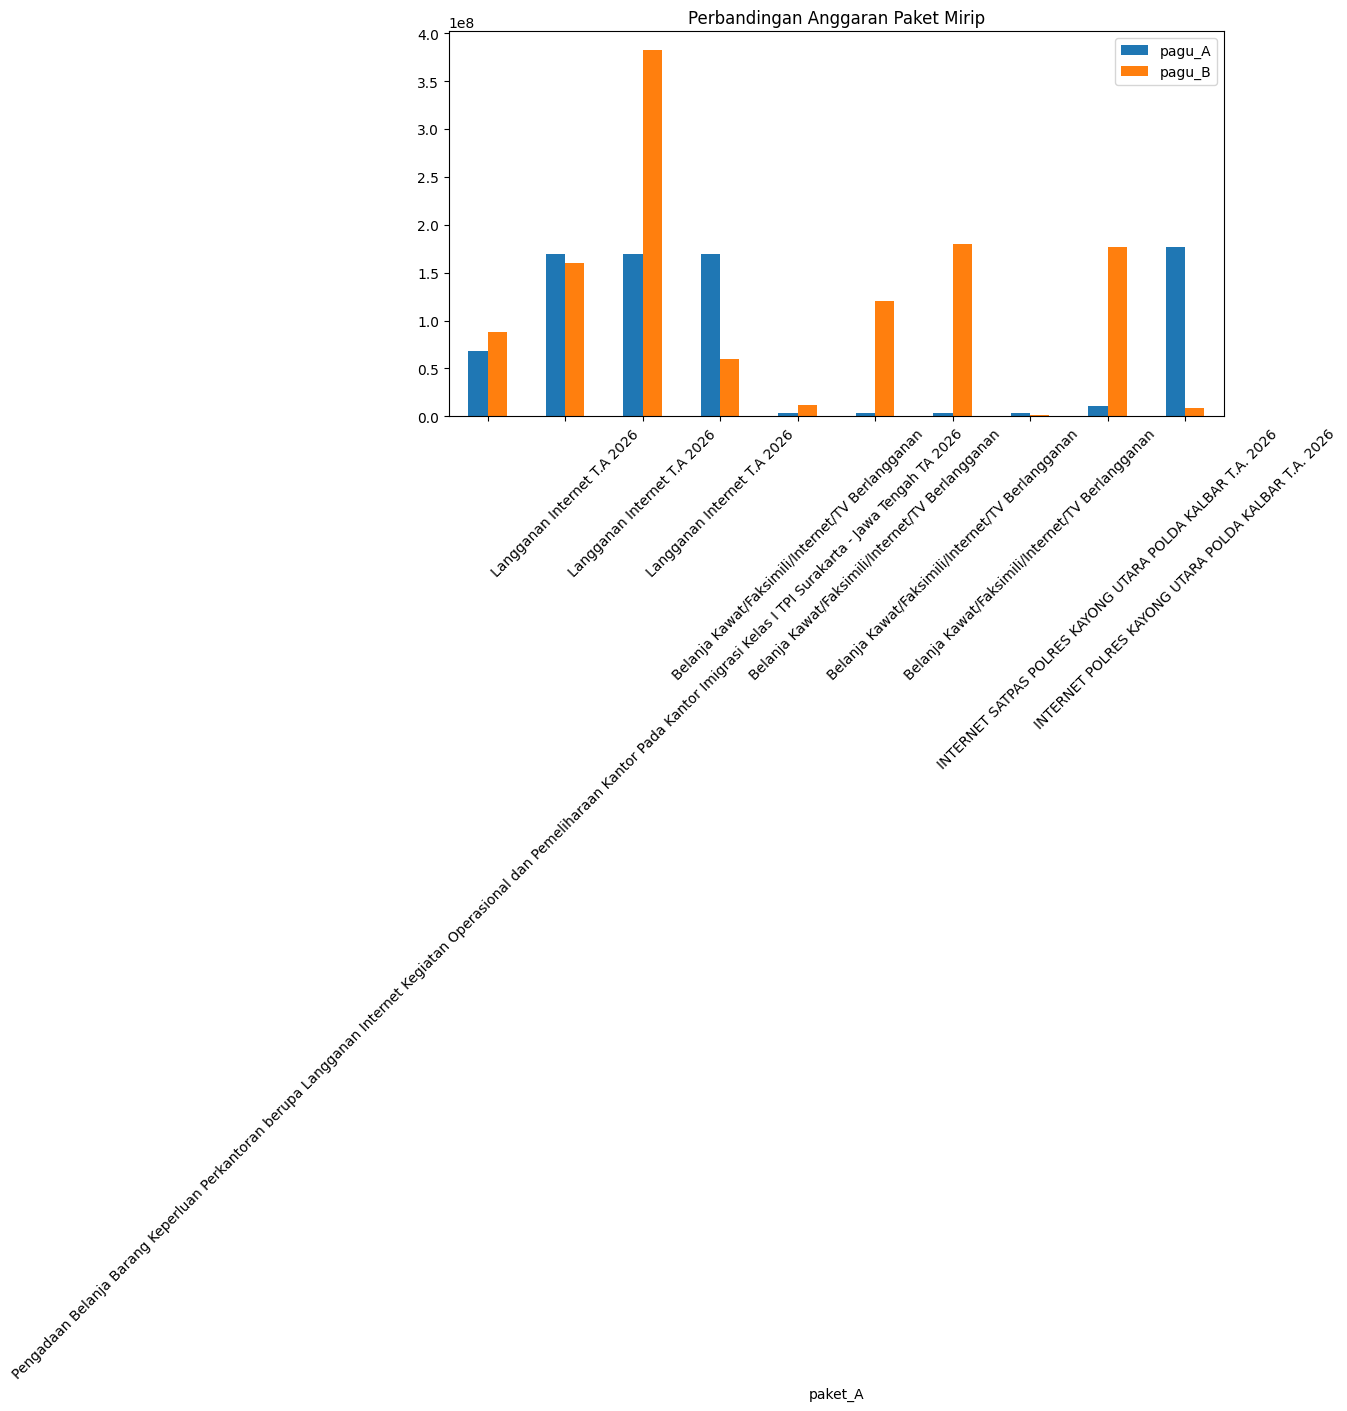

In [ ]:
import matplotlib.pyplot as plt

anomali.head(10).plot(
    kind='bar',
    x='paket_A',
    y=['pagu_A','pagu_B'],
    figsize=(10,5)
)

plt.title("Perbandingan Anggaran Paket Mirip")
plt.xticks(rotation=45)
plt.show()



> Distribusi selisih



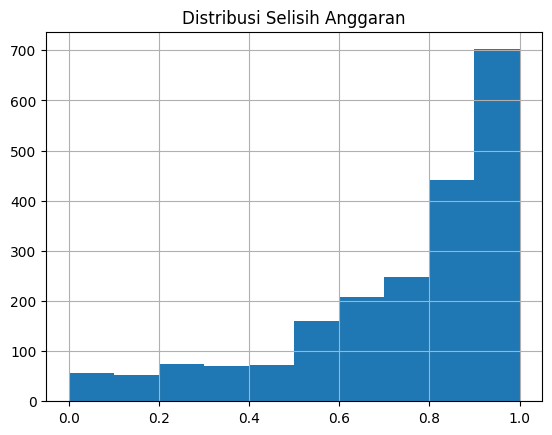

In [ ]:
anomali['persen_selisih'].hist()
plt.title("Distribusi Selisih Anggaran")
plt.show()

In [108]:
anomali = pairs_filtered[
    (pairs_filtered['sim_nama'] >= 0.8) &
    (pairs_filtered['prediksi'] == False)
].copy()

anomali.head(20)

,idx1,idx2,paket_A,paket_B,sim_nama,label,weighted_score,prediksi,score_paket,score_uraian,score_metode
462,2,1295,Langganan Internet T.A 2026,Biaya Internet T.A 2026,0.830115,NaN,0.320890,False,0.318816,0.002074,0.0
463,2,2669,Langganan Internet T.A 2026,INTERNET T.A. 2026,0.970262,NaN,0.676734,False,0.576734,0.000000,0.1
464,2,2948,Langganan Internet T.A 2026,Biaya Internet T.A. 2026,0.830115,NaN,0.350432,False,0.318816,0.031617,0.0
1076,9,3069,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.835089,NaN,0.718192,False,0.618192,0.000000,0.1
2380,13,2503,Belanja Kawat/Faksimili/Internet/TV Berlangganan,nja Kawat/Faksimili/Internet/TV Berlangganan,0.912853,NaN,0.430077,False,0.330077,0.000000,0.1
2412,13,2837,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.816635,NaN,0.702581,False,0.700000,0.002581,0.0
2439,13,2987,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.841583,NaN,0.361582,False,0.361582,0.000000,0.0
2443,13,3077,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Kawat/Faksimili/Internet/TV Berlangganan,0.912853,NaN,0.652129,False,0.652129,0.000000,0.0
4091,18,27,INTERNET SATPAS POLRES KAYONG UTARA POLDA KALB...,INTERNET POLRES KAYONG UTARA POLDA KALBAR T.A....,0.880470,NaN,0.716047,False,0.613051,0.002996,0.1
4092,18,33,INTERNET SATPAS POLRES KAYONG UTARA POLDA KALB...,INTERNET PATROLI SIBER DAN SKCK ONLINE POLRES ...,0.851893,NaN,0.501992,False,0.393430,0.008562,0.1


In [109]:
anomali_sorted = anomali.sort_values(
    by='sim_nama',
    ascending=False
)

anomali_sorted.head(10)

,idx1,idx2,paket_A,paket_B,sim_nama,label,weighted_score,prediksi,score_paket,score_uraian,score_metode
29893,177,2166,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.976560,NaN,0.420395,False,0.383356,0.037040,0.0
463,2,2669,Langganan Internet T.A 2026,INTERNET T.A. 2026,0.970262,NaN,0.676734,False,0.576734,0.000000,0.1
258380,2267,2327,Belanja Kawat /Faksimili/Internet/TV Berlangga...,Belanja Kawat/Faximili/Internet/TV berlanggana...,0.967508,NaN,0.556746,False,0.401289,0.055456,0.1
137116,726,2578,Langganan Biaya Internet,Biaya Internet,0.962821,NaN,0.687422,False,0.639923,0.047498,0.0
6920,32,726,BIAYA INTERNET,Langganan Biaya Internet,0.962821,NaN,0.671667,False,0.639923,0.031743,0.0
28820,170,726,BIAYA INTERNET,Langganan Biaya Internet,0.962821,NaN,0.639923,False,0.639923,0.000000,0.0
137115,726,2577,Langganan Biaya Internet,BIAYA INTERNET,0.962821,NaN,0.687422,False,0.639923,0.047498,0.0
137122,726,3064,Langganan Biaya Internet,BIAYA INTERNET,0.962821,NaN,0.639923,False,0.639923,0.000000,0.0
137118,726,2737,Langganan Biaya Internet,BIAYA INTERNET,0.962821,NaN,0.687422,False,0.639923,0.047498,0.0
137111,726,2140,Langganan Biaya Internet,BIAYA INTERNET,0.962821,NaN,0.640861,False,0.639923,0.000938,0.0


In [110]:
aneh = pairs_filtered[
    (pairs_filtered['prediksi'] == True) &
    (pairs_filtered['score_uraian'] < 0.1)
]

aneh.head(10)

,idx1,idx2,paket_A,paket_B,sim_nama,label,weighted_score,prediksi,score_paket,score_uraian,score_metode
2308,13,1933,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Kawat/Faksimili/Internet/TV Berlangganan,0.912853,NaN,0.752129,True,0.652129,0.000000,0.1
10855,71,354,Pengadaan Langganan Internet TA 2026,Langganan Internet TA 2026,0.889536,NaN,0.750231,True,0.634134,0.016097,0.1
13275,80,2837,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.816635,NaN,0.813693,True,0.700000,0.013693,0.1
13306,80,3077,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Kawat/Faksimili/Internet/TV Berlangganan,0.912853,NaN,0.824543,True,0.652129,0.072414,0.1
16646,93,2837,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Belanja Kawat/Faksimili/Internet/TV Berlanggan...,0.816635,NaN,0.861171,True,0.700000,0.061171,0.1
16677,93,3077,Belanja Kawat/Faksimili/Internet/TV Berlangganan,Kawat/Faksimili/Internet/TV Berlangganan,0.912853,NaN,0.752129,True,0.652129,0.000000,0.1
21863,116,139,Belanja Langganan Internet Service Provider 1,Langganan Internet Service Provider,0.888584,NaN,0.808478,True,0.684368,0.024110,0.1
21864,116,543,Belanja Langganan Internet Service Provider 1,Langganan Internet Service Provider,0.888584,NaN,0.802683,True,0.684368,0.018315,0.1
21865,116,963,Belanja Langganan Internet Service Provider 1,Pengadaan Jasa Langganan Internet Service Prov...,0.843269,NaN,0.795552,True,0.625677,0.069875,0.1
21866,116,1017,Belanja Langganan Internet Service Provider 1,Belanja Langganan Internet Service Provider 2,0.848885,NaN,0.853912,True,0.700000,0.053912,0.1
